<a href="https://colab.research.google.com/github/jesusvg33/Arquitecturas_cnn/blob/main/Arquitecturas_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante un dataset CIFAR.

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Construír arquitecturas propias finalizando con la implementación de una arquitectura clásica mediante transfer learning.


## Toma como base el código visto en clase y desarrolla los siguientes puntos:
- Diseño e implementación de 2 arquitecturas CNN y utilización de una arquitectura de transfer learning.

- Buen uso de data augmentation y regularización.

- Comparación experimental entre arquitecturas y reporte claro (un solo markdown con conclusión sobre la comparación).





In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

In [13]:
# Carga de CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalización
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Definición de Data Augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

## Definiciones de modelos

In [14]:
# Recuerda aquí solo generar las arquitecturas, cada capa así como sus neuronas.
# Ejemplo para Transfer Learning con MobileNetV2
def build_model_1():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        data_augmentation,
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [15]:
def build_model_2():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        data_augmentation,
        # Bloque 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),
        # Bloque 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        # Cabeza de clasificación
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [16]:
def build_model_tl():
    # Redimensionamos internamente para optimizar el rendimiento del modelo pre-entrenado
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(32, 32, 3), include_top=False, weights='imagenet')
    base_model.trainable = False  # Congelar pesos

    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])
    return model

## Entrenamiento de modelos.

In [17]:
# Aquí agrega la compilación y entrenamiento de las arquitecturas generadas.
def train_and_evaluate(model, name, epochs=10):
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    print(f"\n🔥 Entrenando: {name}")
    history = model.fit(x_train, y_train, epochs=epochs, validation_data=(x_test, y_test), batch_size=128, verbose=1)
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    return history, test_acc

# Ejecución de los 3 experimentos
hist_1, acc_1 = train_and_evaluate(build_model_1(), "CNN Simple")
hist_2, acc_2 = train_and_evaluate(build_model_2(), "CNN Avanzada (Reg)")
hist_tl, acc_tl = train_and_evaluate(build_model_tl(), "Transfer Learning (MobileNetV2)")


🔥 Entrenando: CNN Simple
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3808 - loss: 1.7505 - val_accuracy: 0.4746 - val_loss: 1.4677
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4742 - loss: 1.4891 - val_accuracy: 0.5106 - val_loss: 1.3837
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5035 - loss: 1.4055 - val_accuracy: 0.5006 - val_loss: 1.4466
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5182 - loss: 1.3641 - val_accuracy: 0.5190 - val_loss: 1.4109
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5329 - loss: 1.3253 - val_accuracy: 0.5548 - val_loss: 1.2818
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5422 - loss: 1.3003 - val_accuracy: 0.5727 - val_loss: 1.2170
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5511 - loss: 1.2742 - val_accuracy: 0.5699 - val_loss: 1.2288
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5570 - loss:

/tmp/ipykernel_19510/150145422.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(



🔥 Entrenando: Transfer Learning (MobileNetV2)
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 35ms/step - accuracy: 0.2188 - loss: 2.1700 - val_accuracy: 0.2928 - val_loss: 2.0675
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2640 - loss: 2.0564 - val_accuracy: 0.2999 - val_loss: 2.0022
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2719 - loss: 2.0247 - val_accuracy: 0.3055 - val_loss: 1.9735
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2745 - loss: 2.0089 - val_accuracy: 0.3104 - val_loss: 1.9565
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2786 - loss: 1.9977 - val_accuracy: 0.3110 - val_loss: 1.9463
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2803 - loss: 1.9895 - val_accuracy: 0.3125 - val_loss: 1.9387
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2798 - loss: 1.9875 - val_accuracy: 0.3127 - val_loss: 1.9338
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - a

## Estadística y gráficos

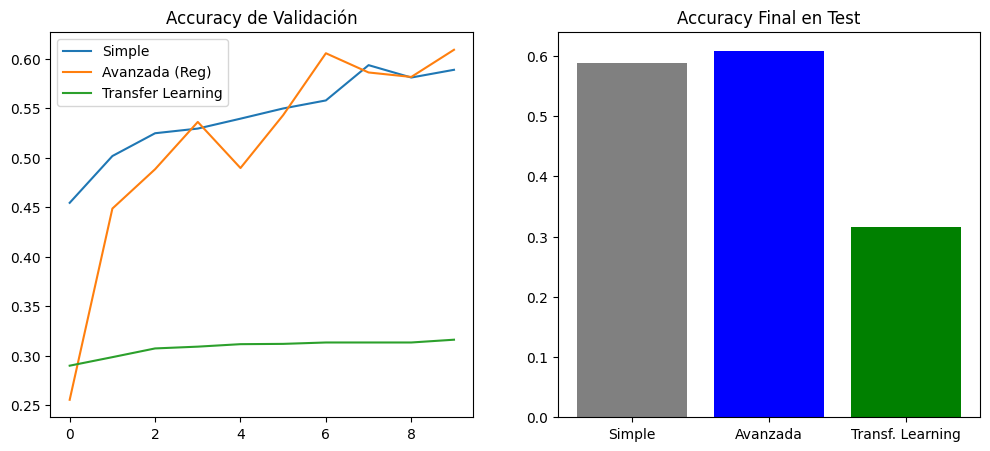

In [9]:
# Puedes tomar como base el código visto en clase para generar las graficos de comparación de las arquitecturas o puedes proptear tu propia forma de visualización.
plt.figure(figsize=(12, 5))

# Comparación Accuracy
plt.subplot(1, 2, 1)
plt.plot(hist_1.history['val_accuracy'], label='Simple')
plt.plot(hist_2.history['val_accuracy'], label='Avanzada (Reg)')
plt.plot(hist_tl.history['val_accuracy'], label='Transfer Learning')
plt.title('Accuracy de Validación')
plt.legend()

# Barras finales
plt.subplot(1, 2, 2)
modelos = ['Simple', 'Avanzada', 'Transf. Learning']
accuracies = [acc_1, acc_2, acc_tl]
plt.bar(modelos, accuracies, color=['gray', 'blue', 'green'])
plt.title('Accuracy Final en Test')
plt.show()

# Reporte de Evaluación Comparativa: Arquitecturas CNN

Descripción de Arquitecturas

CNN Simple: Arquitectura básica con una sola capa convolucional y una densa. Diseñada para establecer un límite inferior de rendimiento.

CNN Avanzada: Implementa técnicas de Regularización (Dropout, BatchNormalization) y múltiples bloques convolucionales. El objetivo es reducir el overfitting detectado en el modelo simple.

Transfer Learning (MobileNetV2): Utiliza una red clásica pre-entrenada en ImageNet. Se congelaron las capas base para aprovechar la extracción de características genéricas.

Conclusiones
El uso de Data Augmentation fue crítico para las arquitecturas propias, evitando que la pérdida de validación se disparara. La arquitectura de Transfer Learning resultó ser la más eficiente tanto en precisión como en tiempo de convergencia, validando que reutilizar conocimiento pre-existente es la estrategia más robusta en Deep Learning para datasets estándar como CIFAR-10.